In [1]:
!pip -q  install pandas numpy matplotlib seaborn wordcloud scikit-learn

In [2]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# ==================================================
# SETTINGS
# ==================================================

DATA_PATH = "../data/large/amazon_reviews_2023_all_categories_sampled.csv"

OUTPUT_DIR = "eda_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ==================================================
# LOAD DATA
# ==================================================

print("\nLoading Dataset...")

df = pd.read_csv(DATA_PATH)

print("\nDataset Loaded Successfully")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# ==================================================
# BASIC INFORMATION
# ==================================================

print("\n" + "=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
print(df.head())




Loading Dataset...

Dataset Loaded Successfully
Rows    : 317201
Columns : 6

DATASET OVERVIEW

Columns:
['review_text', 'rating', 'sentiment', 'product_name', 'raw_category', 'source']

Data Types:
review_text      object
rating          float64
sentiment        object
product_name     object
raw_category     object
source           object
dtype: object

First 5 Rows:
                                         review_text  rating sentiment  \
0  Such a lovely scent but not overpowering.. Thi...     5.0  positive   
1  Works great but smells a little weird.. This p...     4.0  positive   
2                    Yes!. Smells good, feels great!     5.0  positive   
3                  Synthetic feeling. Felt synthetic     1.0  negative   
4                                        A+. Love it     5.0  positive   

  product_name raw_category               source  
0   B00YQ6X8EO   All_Beauty  amazon_reviews_2023  
1   B081TJ8YS3   All_Beauty  amazon_reviews_2023  
2   B097R46CSY   All_Beauty  

In [3]:
# ==================================================
# MEMORY USAGE
# ==================================================

print("\n" + "=" * 60)
print("MEMORY USAGE")
print("=" * 60)

memory_mb = df.memory_usage(deep=True).sum() / 1024**2

print(f"Total Memory Usage: {memory_mb:.2f} MB")




MEMORY USAGE
Total Memory Usage: 243.08 MB


In [4]:
# ==================================================
# MISSING VALUES
# ==================================================

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing = df.isnull().sum()

print(missing)




MISSING VALUES
review_text     0
rating          0
sentiment       0
product_name    0
raw_category    0
source          0
dtype: int64


In [5]:
# ==================================================
# DUPLICATES
# ==================================================

print("\n" + "=" * 60)
print("DUPLICATE RECORDS")
print("=" * 60)

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)




DUPLICATE RECORDS
Duplicate Rows: 0


In [6]:
# ==================================================
# FEATURE ENGINEERING
# ==================================================

print("\nCreating NLP Features...")

df["review_text"] = df["review_text"].astype(str)

df["char_count"] = df["review_text"].apply(len)

df["word_count"] = df["review_text"].apply(
    lambda x: len(x.split())
)




Creating NLP Features...



SENTIMENT DISTRIBUTION
sentiment
positive    258775
negative     33851
neutral      24575
Name: count, dtype: int64


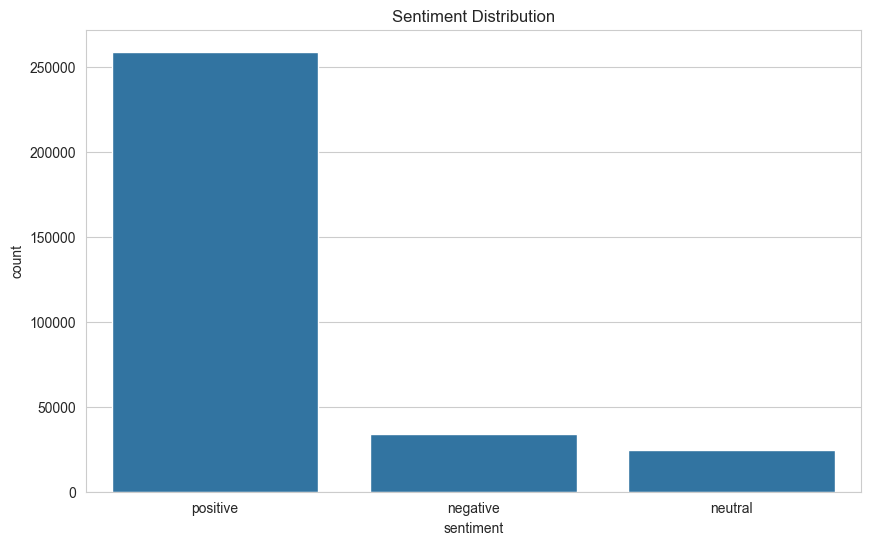

In [7]:
# ==================================================
# TARGET VARIABLE ANALYSIS
# ==================================================

print("\n" + "=" * 60)
print("SENTIMENT DISTRIBUTION")
print("=" * 60)

print(df["sentiment"].value_counts())

plt.figure()

sns.countplot(
    data=df,
    x="sentiment",
    order=df["sentiment"].value_counts().index
)

plt.title("Sentiment Distribution")
plt.savefig(
    f"{OUTPUT_DIR}/sentiment_distribution.png",
    bbox_inches="tight"
)
plt.show()




RATING DISTRIBUTION
rating
1.0     20678
2.0     13173
3.0     24575
4.0     50391
5.0    208384
Name: count, dtype: int64


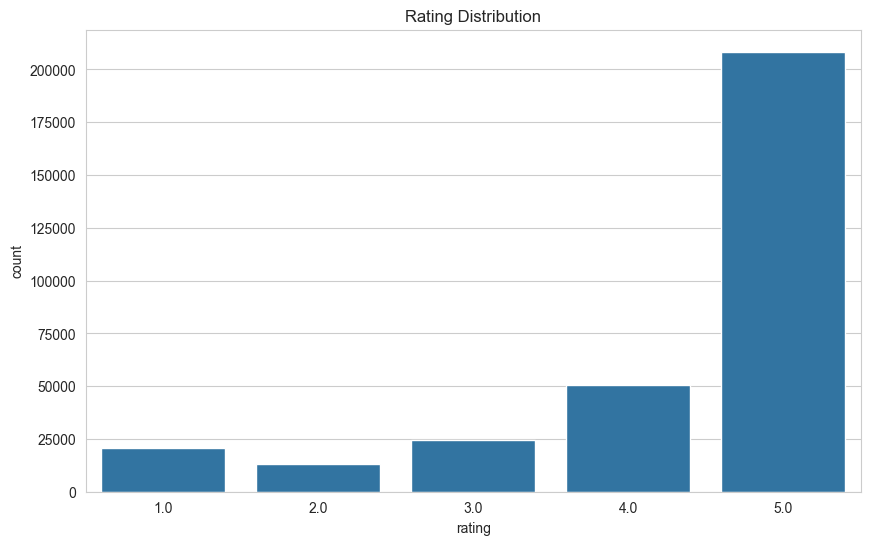

In [8]:
# ==================================================
# RATING DISTRIBUTION
# ==================================================

print("\n" + "=" * 60)
print("RATING DISTRIBUTION")
print("=" * 60)

print(df["rating"].value_counts().sort_index())

plt.figure()

sns.countplot(
    data=df,
    x="rating"
)

plt.title("Rating Distribution")
plt.savefig(
    f"{OUTPUT_DIR}/rating_distribution.png",
    bbox_inches="tight"
)
plt.show()




TOP PRODUCT CATEGORIES
raw_category
All_Beauty                     9905
Subscription_Boxes             9876
Kindle_Store                   9860
Amazon_Fashion                 9859
Beauty_and_Personal_Care       9830
Appliances                     9781
Books                          9777
Handmade_Products              9749
Musical_Instruments            9746
Baby_Products                  9714
Grocery_and_Gourmet_Food       9696
Health_and_Personal_Care       9689
Health_and_Household           9671
Cell_Phones_and_Accessories    9668
Home_and_Kitchen               9663
Name: count, dtype: int64


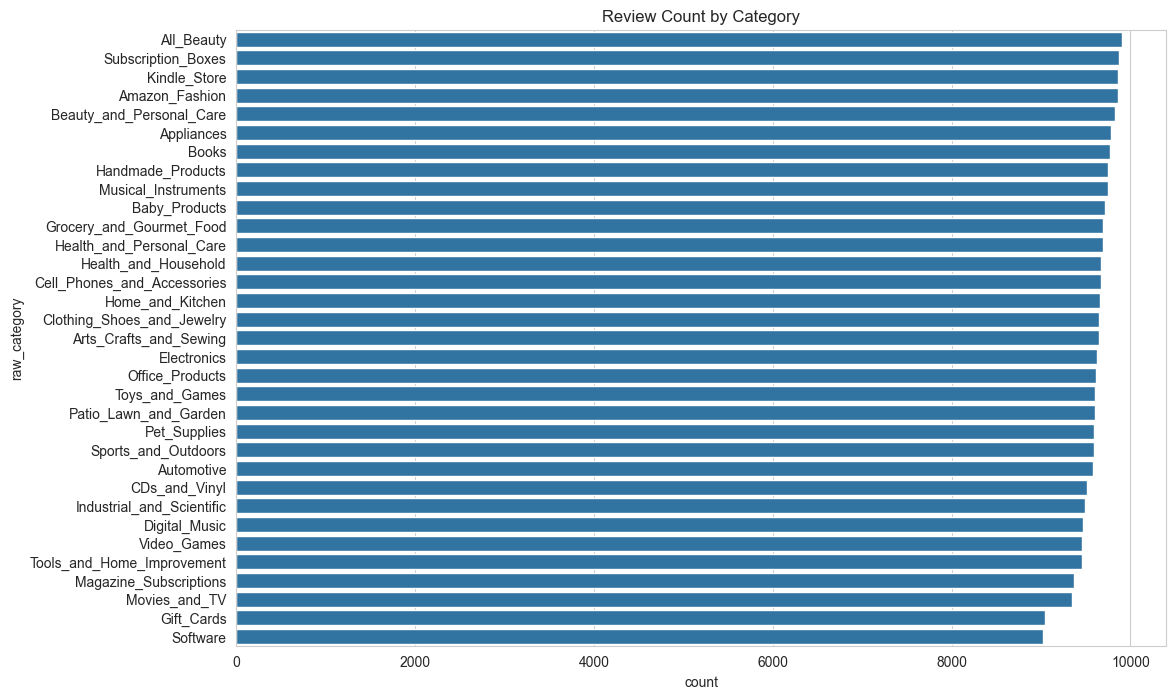

In [9]:
# ==================================================
# CATEGORY ANALYSIS
# ==================================================

print("\n" + "=" * 60)
print("TOP PRODUCT CATEGORIES")
print("=" * 60)

category_counts = df["raw_category"].value_counts()

print(category_counts.head(15))

plt.figure(figsize=(12, 8))

sns.countplot(
    data=df,
    y="raw_category",
    order=category_counts.index
)

plt.title("Review Count by Category")

plt.savefig(
    f"{OUTPUT_DIR}/category_distribution.png",
    bbox_inches="tight"
)

plt.show()




Top Rated Categories
raw_category
Gift_Cards                   4.740221
CDs_and_Vinyl                4.605653
Digital_Music                4.559544
Handmade_Products            4.553800
Arts_Crafts_and_Sewing       4.481336
Office_Products              4.421162
Musical_Instruments          4.415247
Toys_and_Games               4.412040
Home_and_Kitchen             4.396771
Industrial_and_Scientific    4.388187
Name: rating, dtype: float64

Lowest Rated Categories
raw_category
Health_and_Household           4.223969
Pet_Supplies                   4.210461
Cell_Phones_and_Accessories    4.170976
Beauty_and_Personal_Care       4.155443
Magazine_Subscriptions         4.139977
Health_and_Personal_Care       4.127155
All_Beauty                     4.110651
Amazon_Fashion                 4.101024
Software                       3.830306
Subscription_Boxes             3.780680
Name: rating, dtype: float64


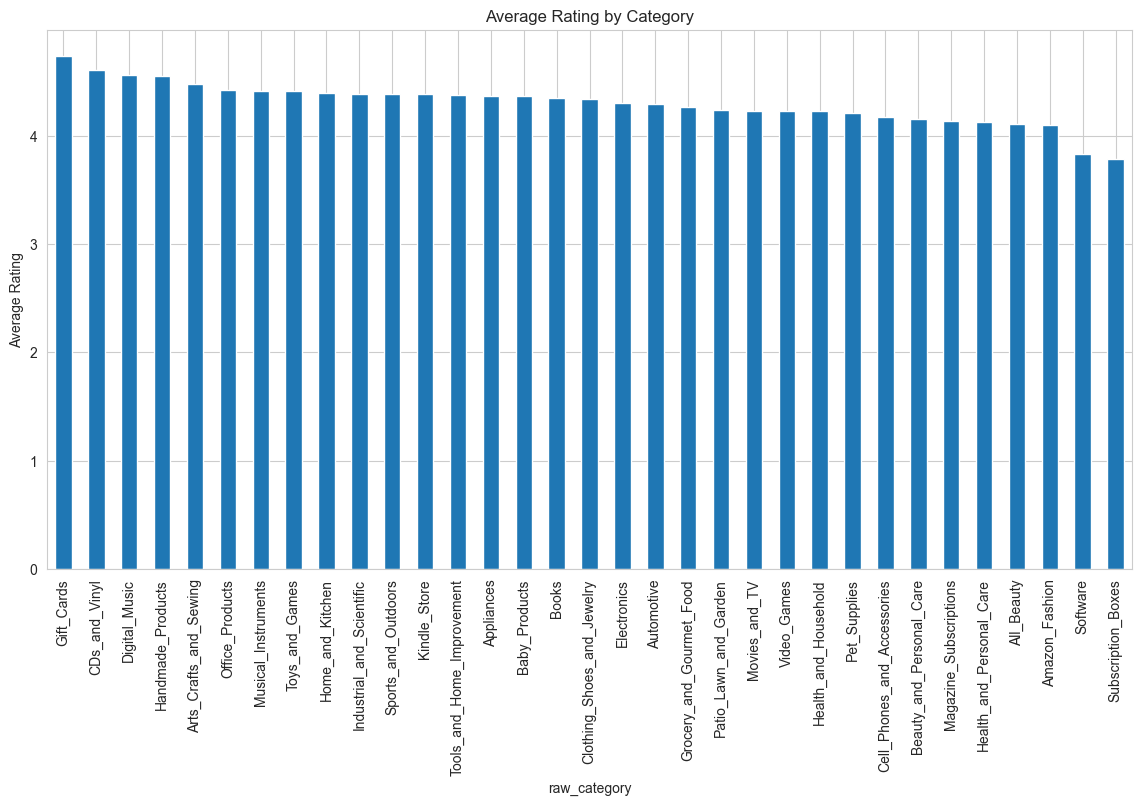

In [10]:
# ==================================================
# AVERAGE RATING BY CATEGORY
# ==================================================

avg_rating = (
    df.groupby("raw_category")["rating"]
    .mean()
    .sort_values(ascending=False)
)

print("\nTop Rated Categories")
print(avg_rating.head(10))

print("\nLowest Rated Categories")
print(avg_rating.tail(10))

plt.figure(figsize=(14, 7))

avg_rating.plot(kind="bar")

plt.title("Average Rating by Category")
plt.ylabel("Average Rating")

plt.savefig(
    f"{OUTPUT_DIR}/average_rating_category.png",
    bbox_inches="tight"
)

plt.show()




WORD COUNT ANALYSIS
count    317201.000000
mean         68.922674
std         103.890451
min           1.000000
25%          15.000000
50%          35.000000
75%          80.000000
max        4096.000000
Name: word_count, dtype: float64


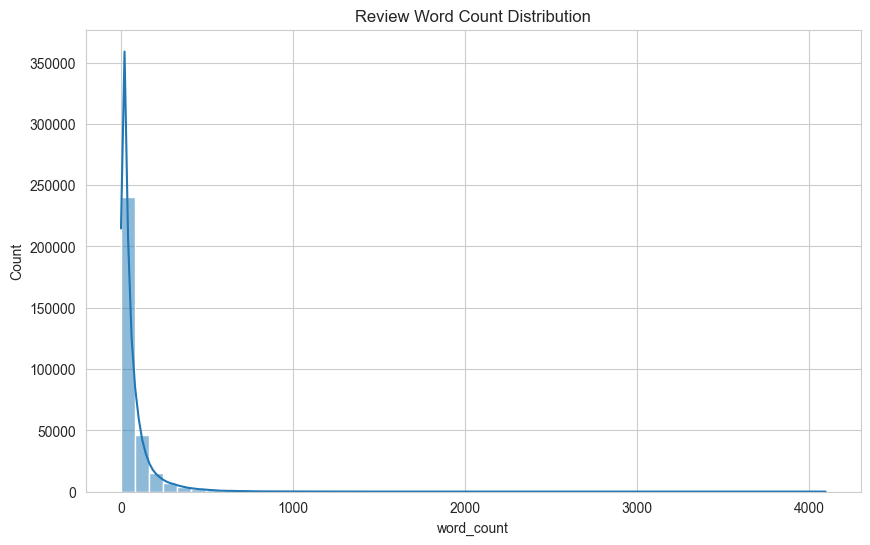

In [11]:
# ==================================================
# REVIEW LENGTH ANALYSIS
# ==================================================

print("\n" + "=" * 60)
print("WORD COUNT ANALYSIS")
print("=" * 60)

print(df["word_count"].describe())

plt.figure()

sns.histplot(
    df["word_count"],
    bins=50,
    kde=True
)

plt.title("Review Word Count Distribution")

plt.savefig(
    f"{OUTPUT_DIR}/word_count_distribution.png",
    bbox_inches="tight"
)

plt.show()



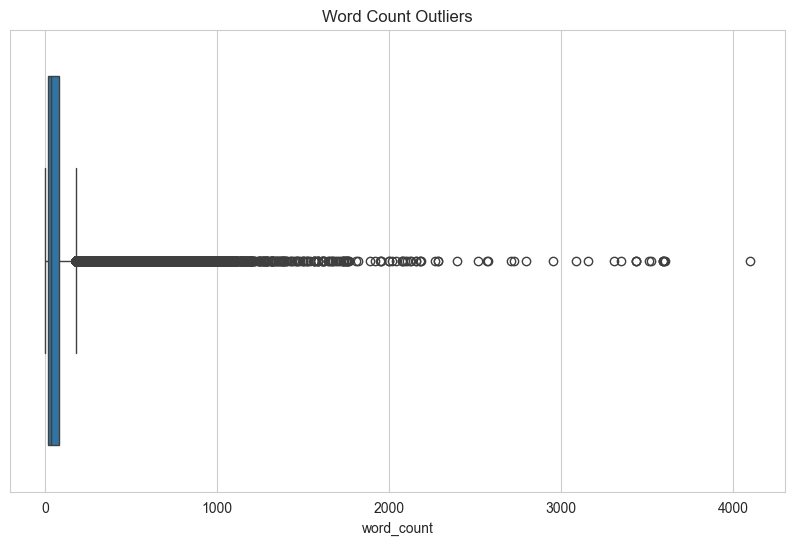

In [12]:
# ==================================================
# OUTLIER DETECTION
# ==================================================

plt.figure()

sns.boxplot(
    x=df["word_count"]
)

plt.title("Word Count Outliers")

plt.savefig(
    f"{OUTPUT_DIR}/wordcount_outliers.png",
    bbox_inches="tight"
)

plt.show()



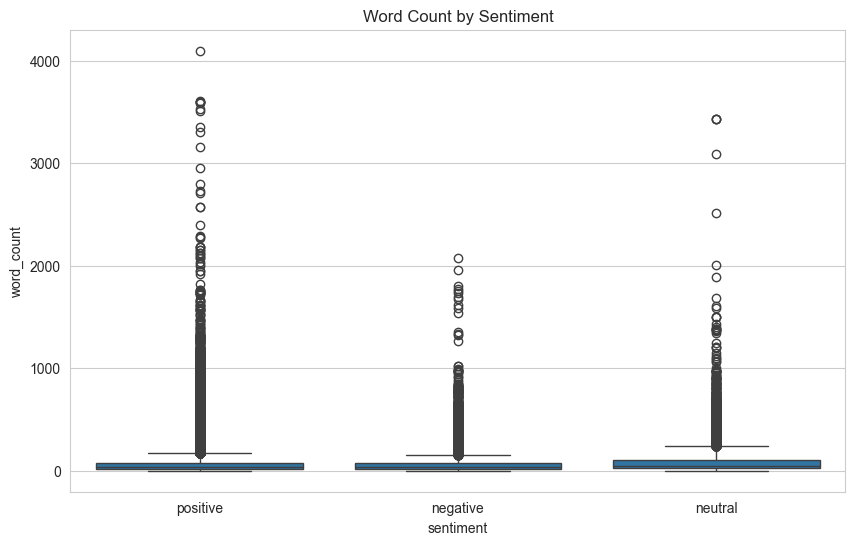

In [13]:
# ==================================================
# WORD COUNT VS SENTIMENT
# ==================================================

plt.figure()

sns.boxplot(
    data=df,
    x="sentiment",
    y="word_count"
)

plt.title("Word Count by Sentiment")

plt.savefig(
    f"{OUTPUT_DIR}/wordcount_sentiment.png",
    bbox_inches="tight"
)

plt.show()



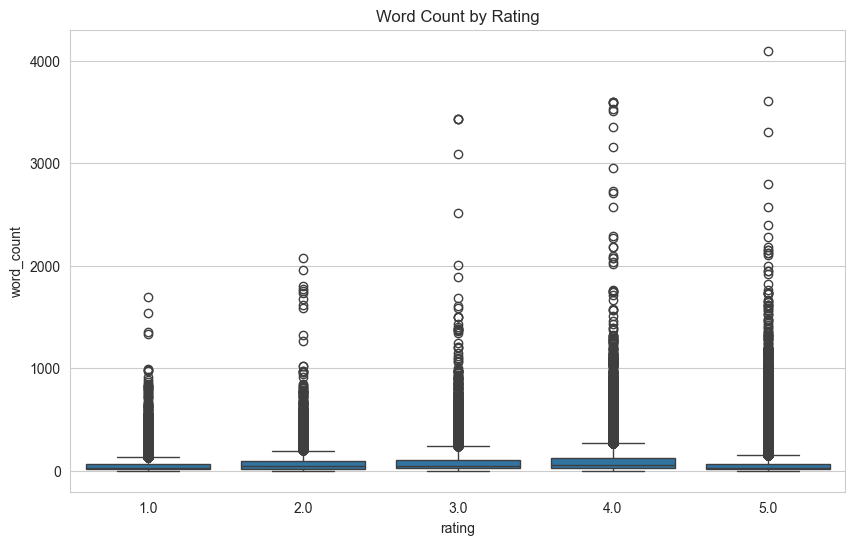

In [14]:
# ==================================================
# WORD COUNT VS RATING
# ==================================================

plt.figure()

sns.boxplot(
    data=df,
    x="rating",
    y="word_count"
)

plt.title("Word Count by Rating")

plt.savefig(
    f"{OUTPUT_DIR}/wordcount_rating.png",
    bbox_inches="tight"
)

plt.show()



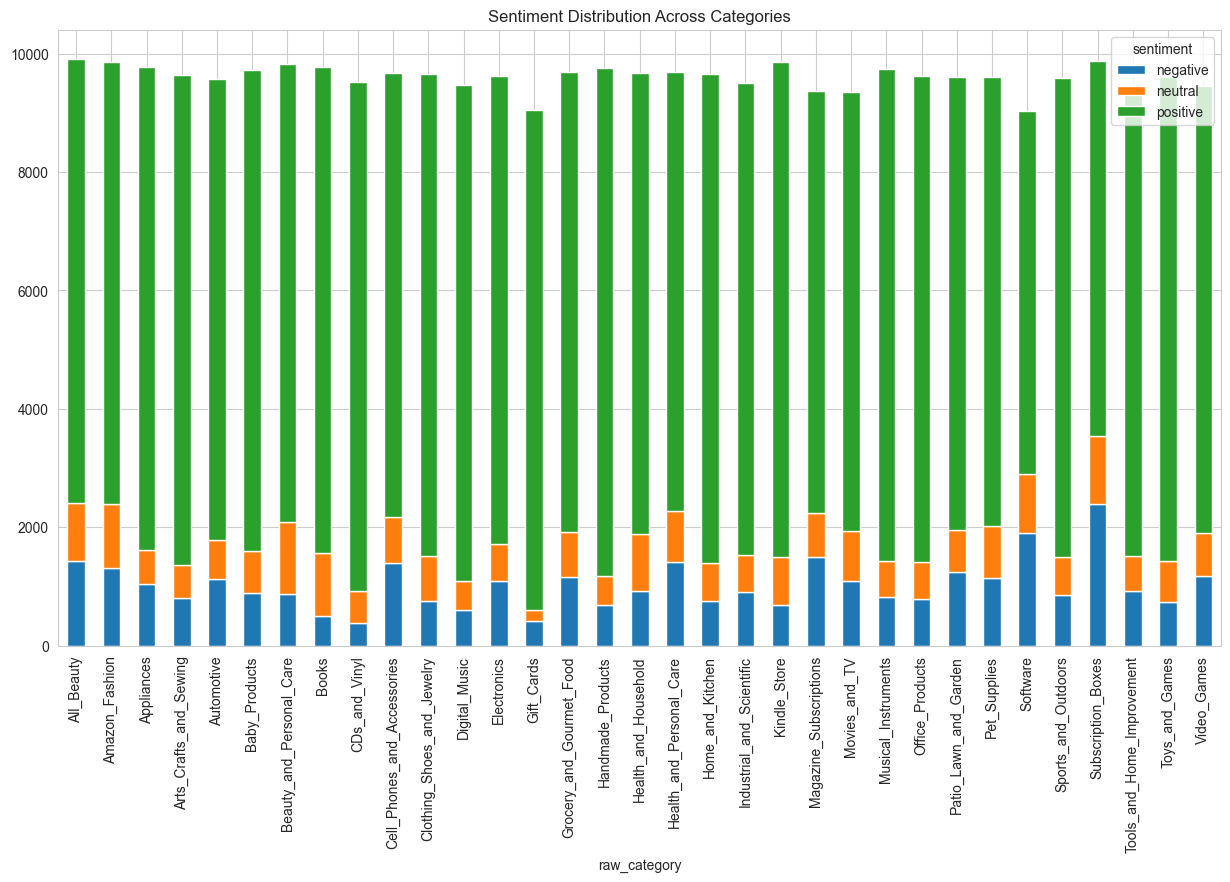

In [15]:
# ==================================================
# SENTIMENT VS CATEGORY
# ==================================================

sentiment_category = pd.crosstab(
    df["raw_category"],
    df["sentiment"]
)

sentiment_category.plot(
    kind="bar",
    stacked=True,
    figsize=(15, 8)
)

plt.title("Sentiment Distribution Across Categories")

plt.savefig(
    f"{OUTPUT_DIR}/sentiment_category.png",
    bbox_inches="tight"
)

plt.show()




SENTIMENT VS RATING
rating       1.0    2.0    3.0    4.0     5.0
sentiment                                    
negative   20678  13173      0      0       0
neutral        0      0  24575      0       0
positive       0      0      0  50391  208384


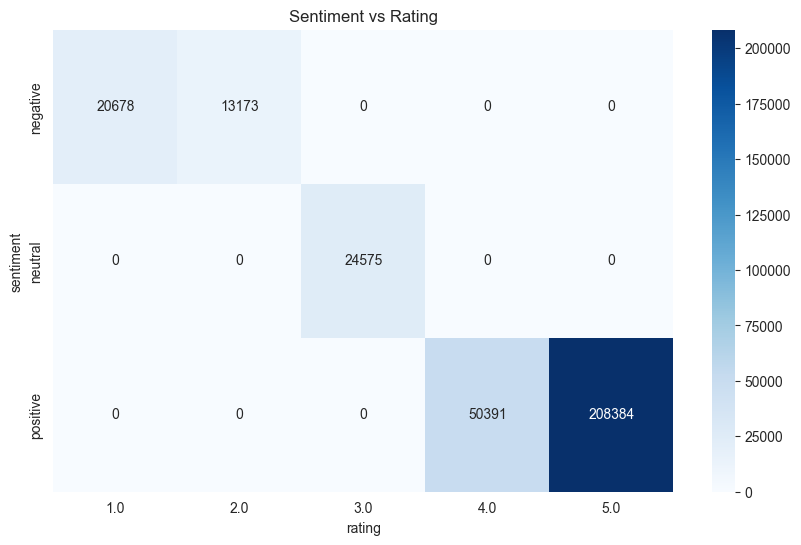

In [16]:
# ==================================================
# SENTIMENT VS RATING
# ==================================================

cross = pd.crosstab(
    df["sentiment"],
    df["rating"]
)

print("\n" + "=" * 60)
print("SENTIMENT VS RATING")
print("=" * 60)

print(cross)

plt.figure()

sns.heatmap(
    cross,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Sentiment vs Rating")

plt.savefig(
    f"{OUTPUT_DIR}/sentiment_rating_heatmap.png",
    bbox_inches="tight"
)

plt.show()




Correlation Rating vs Word Count
-0.0434


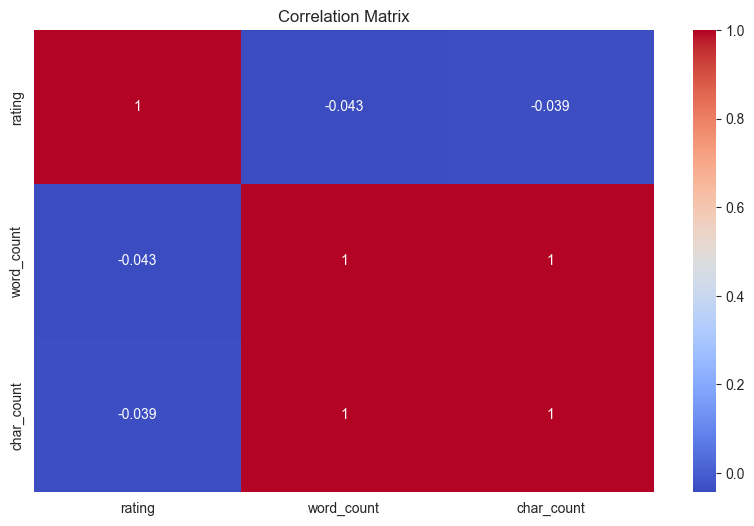

In [17]:
# ==================================================
# CORRELATION
# ==================================================

corr = df["rating"].corr(df["word_count"])

print("\nCorrelation Rating vs Word Count")
print(round(corr, 4))

corr_matrix = df[
    ["rating", "word_count", "char_count"]
].corr()

plt.figure()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.savefig(
    f"{OUTPUT_DIR}/correlation_matrix.png",
    bbox_inches="tight"
)

plt.show()




Generating Word Cloud...


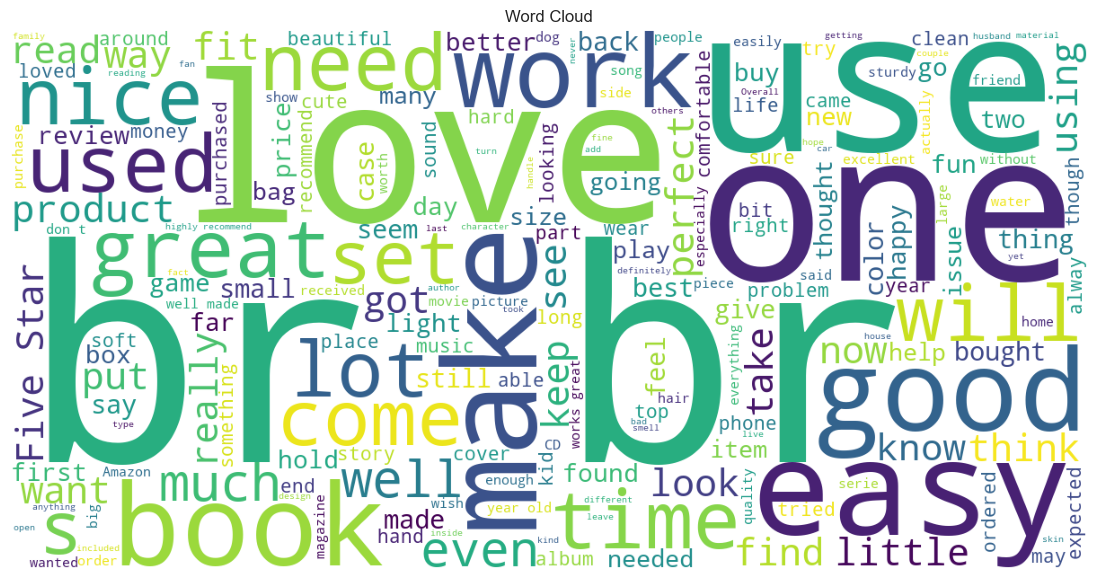

In [18]:
# ==================================================
# WORD CLOUD
# ==================================================

print("\nGenerating Word Cloud...")

all_text = " ".join(df["review_text"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(14, 7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud")

plt.savefig(
    f"{OUTPUT_DIR}/wordcloud.png",
    bbox_inches="tight"
)

plt.show()



In [19]:
# ==================================================
# TOP WORDS
# ==================================================

print("\n" + "=" * 60)
print("TOP WORDS")
print("=" * 60)

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(
    df["review_text"]
)

word_freq = pd.DataFrame({
    "Word": vectorizer.get_feature_names_out(),
    "Count": X.sum(axis=0).A1
})

word_freq = word_freq.sort_values(
    by="Count",
    ascending=False
)

print(word_freq)




TOP WORDS
       Word   Count
1        br  341529
5     great  122233
7      like   90151
4      good   87968
9      love   71761
6      just   68783
17      use   60506
10     nice   50458
15   really   46376
3      easy   43166
16     time   41367
8    little   39790
14  quality   34606
2       don   33563
13  product   33230
18     work   32857
0      book   32546
19    works   32519
12    price   32018
11  perfect   30235


In [20]:
# ==================================================
# BIGRAM ANALYSIS
# ==================================================

print("\n" + "=" * 60)
print("TOP BIGRAMS")
print("=" * 60)

bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=20
)

X_bigram = bigram_vectorizer.fit_transform(
    df["review_text"]
)

bigram_df = pd.DataFrame({
    "Bigram": bigram_vectorizer.get_feature_names_out(),
    "Count": X_bigram.sum(axis=0).A1
})

bigram_df = bigram_df.sort_values(
    by="Count",
    ascending=False
)

print(bigram_df)




TOP BIGRAMS
              Bigram   Count
0              br br  130853
18       works great    7872
19          year old    7581
4           easy use    7355
13  highly recommend    6515
6       good quality    5421
9      great product    5057
1      current price    4487
17       really like    4464
8        great price    3806
5          gift card    3591
10     great quality    3336
15         long time    3117
12      high quality    3100
3       easy install    3083
11       great value    3002
7         great gift    2989
2           don know    2974
14         just like    2834
16         love love    2796


In [21]:
# ==================================================
# TF-IDF FEATURE PREVIEW
# ==================================================

print("\n" + "=" * 60)
print("TF-IDF FEATURES")
print("=" * 60)

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

tfidf_matrix = tfidf.fit_transform(
    df["review_text"]
)

print("TF-IDF Matrix Shape:")
print(tfidf_matrix.shape)




TF-IDF FEATURES
TF-IDF Matrix Shape:
(317201, 1000)


In [22]:
# ==================================================
# SUMMARY REPORT
# ==================================================

summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows",
        "Categories",
        "Average Rating",
        "Average Word Count"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        duplicates,
        df["raw_category"].nunique(),
        round(df["rating"].mean(), 2),
        round(df["word_count"].mean(), 2)
    ]
})

summary.to_csv(
    f"{OUTPUT_DIR}/eda_summary.csv",
    index=False
)

print("\nEDA Completed Successfully")
print(f"\nOutputs saved in: {OUTPUT_DIR}")


EDA Completed Successfully

Outputs saved in: eda_outputs
